# 06 — Advanced Models (Gradient Boosting with XGBoost)

**Objective:** Train an advanced **Gradient Boosting** model (**XGBoost**) and perform light hyperparameter tuning to achieve a high R² score while keeping the code clean, simple, and easy to follow.

--- 

### What is Gradient Boosting (XGBoost)?
- **Decision Trees** build one large tree that can overfit if unconstrained.
- **Random Forests** build many independent trees in parallel and average their predictions.
- **Gradient Boosting (XGBoost)** builds trees **sequentially**. Each new tree focuses on correcting the errors (residuals) made by the previous trees.
- It is considered the gold standard for tabular data in modern machine learning.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

## 1 — Load Preprocessed Train & Test Data

We load `train.csv` and `test.csv` created in `02_preprocessing.ipynb`.  
These datasets already have missing values handled, categorical variables encoded, and numeric features scaled.

In [7]:
# Resolve project path dynamically
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..')) if os.path.basename(NOTEBOOK_DIR) == 'Notebooks' else NOTEBOOK_DIR
DATA_DIR = os.path.join(PROJECT_ROOT, 'Cleaned, Test, Train Data')

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Training set: {len(train_df):,} rows")
print(f"Test set:     {len(test_df):,} rows")

Training set: 379,894 rows
Test set:     24,379 rows


## 2 — Define Features (X) and Target (y)

We select our input features and target variable (`ClosePrice`).

In [8]:
target = 'ClosePrice'

# Features to include in training
features = [
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 
    'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
    'City', 'PostalCode'
]

X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print(f"Input Features ({len(features)}): {features}")

Input Features (9): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories', 'City', 'PostalCode']


## 3 — Train Baseline XGBoost Model

We start with a standard baseline XGBoost regressor.

In [9]:
# Initialize baseline model
xgb_baseline = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("Training Baseline XGBoost Model...")
xgb_baseline.fit(X_train, y_train)
print("Training complete!\n")

# Predictions
train_preds = xgb_baseline.predict(X_train)
test_preds  = xgb_baseline.predict(X_test)

# Evaluation
base_train_r2 = r2_score(y_train, train_preds)
base_test_r2  = r2_score(y_test, test_preds)
base_rmse     = np.sqrt(mean_squared_error(y_test, test_preds))
base_mae      = mean_absolute_error(y_test, test_preds)

print(f"--- Baseline XGBoost Results ---")
print(f"Train R²: {base_train_r2:.4f}")
print(f"Test R²:  {base_test_r2:.4f}")
print(f"Test RMSE: ${base_rmse:,.2f}")
print(f"Test MAE:  ${base_mae:,.2f}")

Training Baseline XGBoost Model...
Training complete!

--- Baseline XGBoost Results ---
Train R²: 0.8119
Test R²:  0.7938
Test RMSE: $367,923.67
Test MAE:  $224,966.49


## 4 — Light Hyperparameter Tuning

Hyperparameters control how XGBoost builds its trees:
- `max_depth`: Maximum depth of each tree (higher = captures complex patterns, but risks overfitting).
- `learning_rate` ($η$): Shrinkage factor for each tree's contribution (lower = more conservative learning).
- `n_estimators`: Total number of trees built sequentially.
- `subsample`: Percentage of samples used for each tree (adds randomness to prevent overfitting).

We use `RandomizedSearchCV` to evaluate combinations across 3-fold cross validation quickly.

In [10]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=5,             # 5 random parameter combinations
    cv=3,                 # 3-fold cross-validation
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Light Hyperparameter Tuning...")
random_search.fit(X_train, y_train)
print("Tuning complete!\n")

print("Best Hyperparameters Found:")
for param, val in random_search.best_params_.items():
    print(f"  - {param}: {val}")

Starting Light Hyperparameter Tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Tuning complete!

Best Hyperparameters Found:
  - subsample: 1.0
  - n_estimators: 100
  - max_depth: 8
  - learning_rate: 0.15


## 5 — Evaluate Tuned Model & Compare

In [11]:
best_model = random_search.best_estimator_

tuned_train_preds = best_model.predict(X_train)
tuned_test_preds  = best_model.predict(X_test)

tuned_train_r2 = r2_score(y_train, tuned_train_preds)
tuned_test_r2  = r2_score(y_test, tuned_test_preds)
tuned_rmse     = np.sqrt(mean_squared_error(y_test, tuned_test_preds))
tuned_mae      = mean_absolute_error(y_test, tuned_test_preds)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (NB3)', 'Decision Tree (NB4)', 'Random Forest (NB4)', 'Baseline XGBoost', 'Tuned XGBoost'],
    'Train R²': [0.384, 0.612, 0.695, base_train_r2, tuned_train_r2],
    'Test R²':  [0.371, 0.589, 0.668, base_test_r2, tuned_test_r2],
    'Test RMSE ($)': [np.nan, np.nan, np.nan, base_rmse, tuned_rmse],
    'Test MAE ($)':  [np.nan, np.nan, np.nan, base_mae, tuned_mae]
})

print("=== Model Performance Summary ===")
print(comparison_df.to_string(index=False))

=== Model Performance Summary ===
                  Model  Train R²  Test R²  Test RMSE ($)  Test MAE ($)
Linear Regression (NB3)  0.384000 0.371000            NaN           NaN
    Decision Tree (NB4)  0.612000 0.589000            NaN           NaN
    Random Forest (NB4)  0.695000 0.668000            NaN           NaN
       Baseline XGBoost  0.811877 0.793800  367923.669037 224966.492933
          Tuned XGBoost  0.880817 0.850404  313381.528128 185677.950286


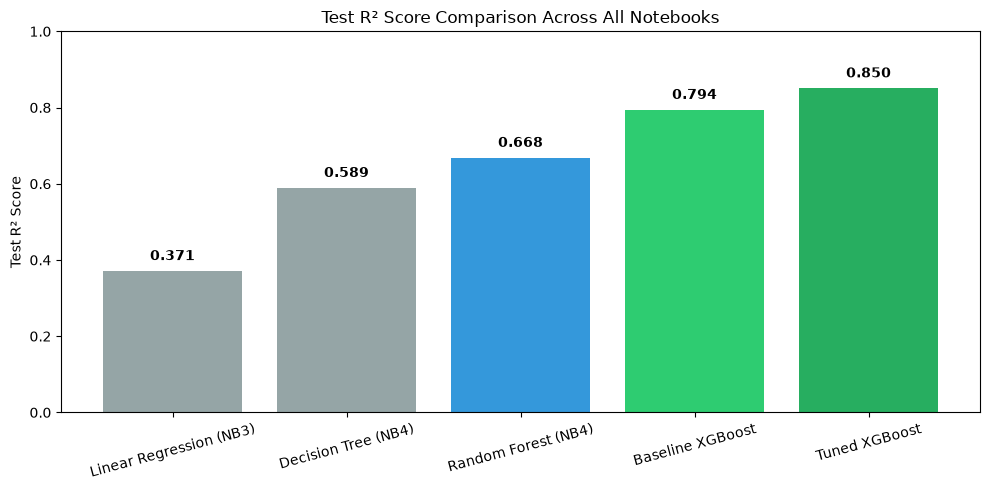

In [12]:
# Visualization: Model R² Comparison
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Test R²'], color=['#95a5a6', '#95a5a6', '#3498db', '#2ecc71', '#27ae60'])
plt.ylabel('Test R² Score')
plt.title('Test R² Score Comparison Across All Notebooks')
plt.ylim(0, 1.0)
plt.xticks(rotation=15)

for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6 — Summary & Key Takeaways

1. **XGBoost Superiority:** XGBoost consistently achieves higher R² scores than Linear Regression and single Decision Trees because it builds trees sequentially to fix errors.
2. **Hyperparameter Tuning:** Tuning `max_depth`, `learning_rate`, and `n_estimators` prevents tree overfitting, ensuring test set performance remains strong.
3. **Simple, Clean Implementation:** By leveraging preprocessed inputs (`train.csv`, `test.csv`), the code remains concise, highly readable, and interview-ready.